# Lista 12

## Plotly Express, Seaborn

(6pkt + 2pkt)

Na liście znajduje się 6 zadań. Po rozwiązaniu zadań, pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

Postaraj się, żeby Twoje wykresy były możliwie podobne do tych w rozwiązaniach.

**Zadania bonusowe**

Dodatkowe zadania na wyższą ocenę oznaczone są ⭐️.

In [20]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


# Zadanie 1 – t-SNE 2D (Plotly Express)


1. Wybierz cechy numeryczne z datasetu `penguins`.
2. Wykonaj redukcję wymiarów **t-SNE do 2D**.
3. Stwórz **interaktywny wykres punktowy** w Plotly Express.
4. Pokoloruj punkty według gatunku (`species`).
5. Dodaj **czytelny hover**, pokazujący wybrane informacje o obserwacji.

In [9]:

from sklearn.manifold import TSNE
import plotly.express as px

# 1. Wybór cech numerycznych
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = penguins[features]
y = penguins["species"]

# 2. t-SNE do 2D
tsne = TSNE(n_components=2)

X_2d = tsne.fit_transform(X)

# 3. DataFrame pod Plotly
df_tsne = pd.DataFrame(X_2d, columns=["tsne_1", "tsne_2"])
df_tsne["species"] = y
df_tsne["island"] = penguins["island"]
df_tsne["sex"] = penguins["sex"]

# 4. Wykres interaktywny
fig = px.scatter(df_tsne, x='tsne_1', y='tsne_2', color='species', hover_data=['species', 'island', 'sex'])

fig.show()

# Zadanie 2 – t-SNE 3D (Plotly Express, pełna interakcja)

1. Wykonaj redukcję t-SNE do **3 wymiarów**.
2. Stwórz **interaktywny wykres 3D**.
3. Pokoloruj punkty według wyspy (`island`).
4. Zadbaj o estetykę: rozmiar punktów, przezroczystość, tytuł.

In [16]:
# 1. t-SNE do 3D
tsne_3d = TSNE(n_components=3)

X_3d = tsne_3d.fit_transform(X)

# 2. DataFrame
df_3d = pd.DataFrame(X_3d, columns=["x", "y", "z"])
df_3d["species"] = penguins["species"]
df_3d["island"] = penguins["island"]

# 3. Wykres 3D
fig = px.scatter_3d(
    df_3d,
    x='x', y='y', z='z',
    color='island',
    hover_data=['species'],
    opacity=0.7,
    title="t-SNE 3D projection of Penguins"
)

# 4. Drobne poprawki estetyczne
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    scene_camera=dict(eye=dict(x=1.4, y=1.4, z=1.2))
)

fig.show()

## Zadanie 3 – sns.jointplot (relacja + rozkłady)

1. Użyj datasetu `penguins` z seaborn.
2. Wykonaj `sns.jointplot`, pokazujący zależność między `flipper_length_mm` i `bill_length_mm`,
1. Dodaj rozróżnienie gatunków (`hue`).

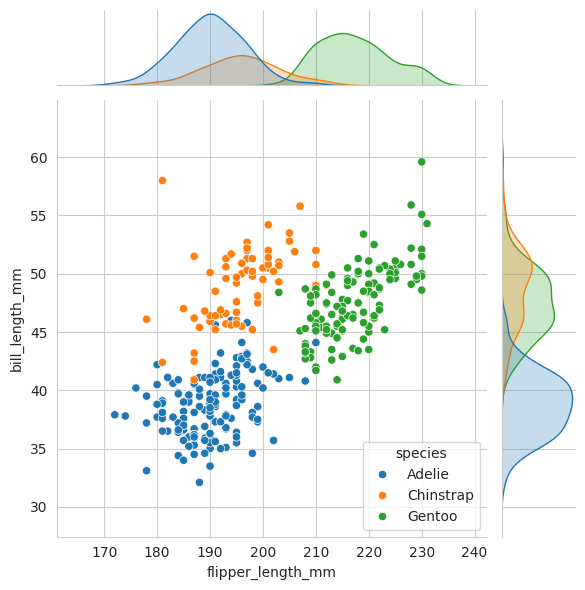

In [23]:
sns.jointplot(penguins, x='flipper_length_mm', y='bill_length_mm', hue='species')
plt.show()

## Zadanie 4 – sns.pairplot (wielowymiarowe relacje)

1. Wykonaj `sns.pairplot` dla datasetu `penguins`.
2. Pokoloruj punkty według `species`.
3. Zmień:

   * typ wykresu na przekątnej (`diag_kind="kde"`),
   * rozmiar wykresów.

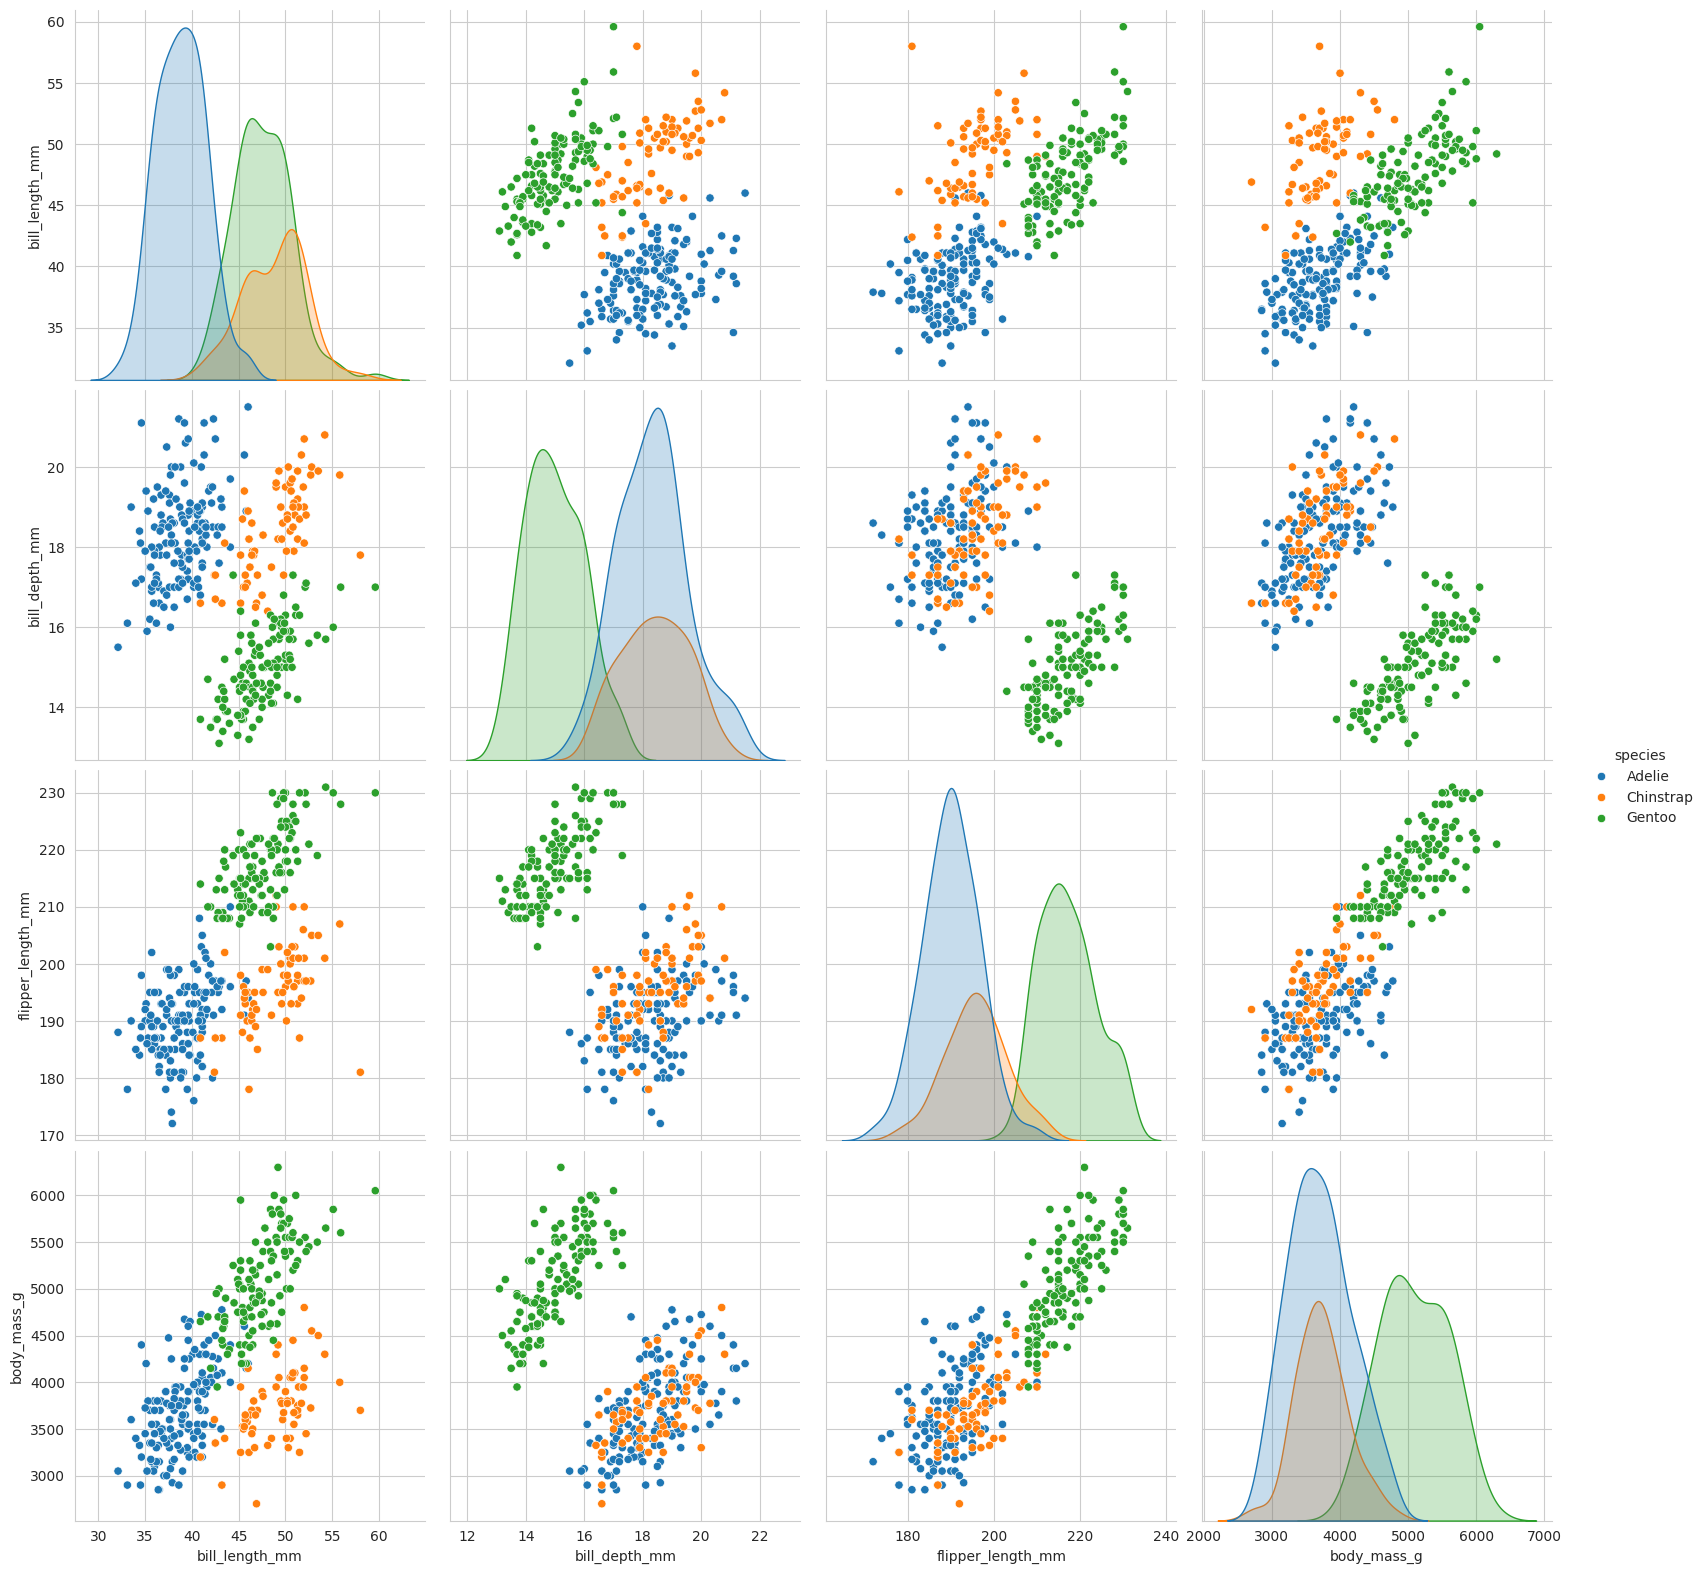

In [29]:
sns.pairplot(data=penguins, hue='species', diag_kind='kde', height=4)
plt.show()

## Zadanie 5 – sns.displot: kilka wykresów obok siebie (FacetGrid)

1. Wykonaj `sns.displot` dla `flipper_length_mm`.
2. Rozdziel wykresy na kolumny według `species`.

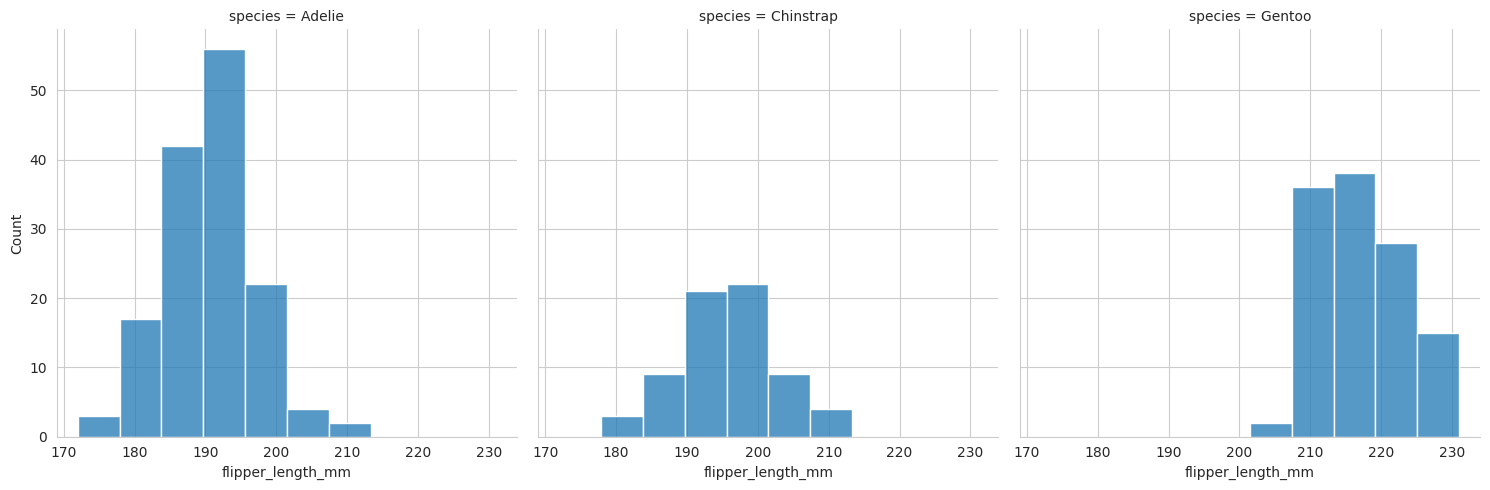

In [40]:
sns.displot(
    data=penguins,
    x="flipper_length_mm",
    col="species"
)

plt.show()

## Zadanie 6 – Łączenie Matplotlib i Seaborn (axes-level)

1. Utwórz figurę z **dwoma wykresami obok siebie** za pomocą funkcji `subplots(...)` z biblioteki `matplotlib` .
2. Po lewej narusuj wykres punktowy (`sns.scatterplot`) dla datasetu penguins.
3. Po prawej histogram (`sns.histplot`) dla datasetu penguins.

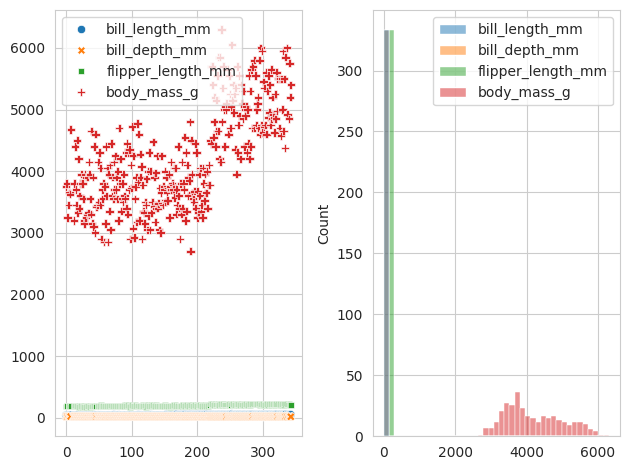

In [43]:
import matplotlib.pyplot as plt

f, axs = plt.subplots(
    1, 2
)

sns.scatterplot(data=penguins, ax=axs[0])
sns.histplot(data=penguins, ax=axs[1])

f.tight_layout()
plt.show()

## ⭐ Zadanie 7 – „Density vs reality”

Na datasetach `diamonds` i `tips`:

1. Porównaj:

   * `displot(kind="kde")`
   * `displot(kind="hist")`
   * `displot(kind="hist", kde=True)`
2. Dopasuj:

   * `bw_adjust`,
   * `cut`.
3. Odpowiedz na pytania:
   1. Jak zmiana parametru bw_adjust wpływa na kształt krzywej KDE? Opisz, co się stanie, gdy:
   
      * bw_adjust jest bardzo małe,
      * bw_adjust jest bardzo duże.
   2. Co robi parametr cut

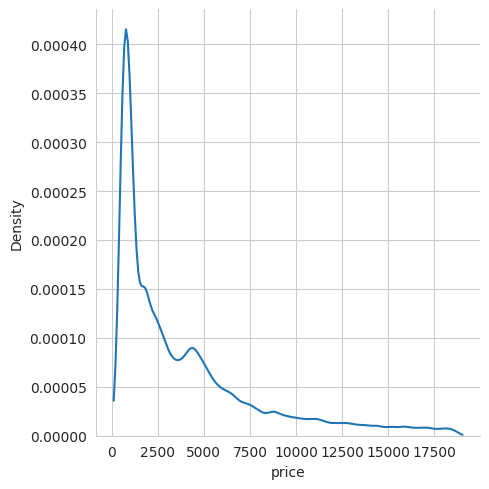

In [63]:
diamonds = sns.load_dataset("diamonds")

# sns.displot(data=diamonds, x='price', kind='kde')
# sns.displot(data=diamonds, x='price', kind='hist')
# sns.displot(data=diamonds, x='price', kind='hist', kde=True)

# sns.displot(data=diamonds, x='price', kind='kde', bw_adjust=0.5, cut=0)
# sns.displot(data=diamonds, x='price', kind='kde', bw_adjust=0.5, cut=1)
# sns.displot(data=diamonds, x='price', kind='kde', bw_adjust=0.5, cut=5)

sns.displot(data=diamonds, x='price', kind='kde', bw_adjust=0.5, cut=1)
plt.show()

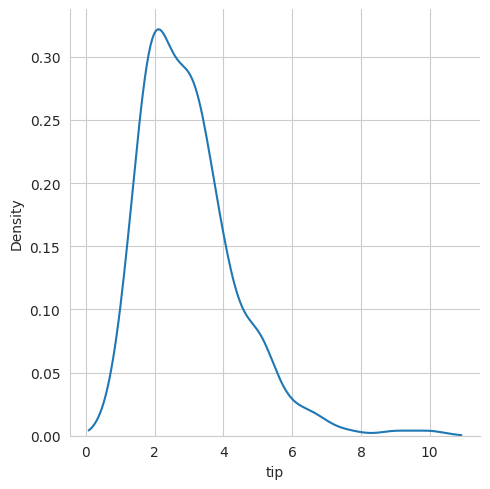

In [74]:
tips = sns.load_dataset("tips")

sns.displot(data=tips, x='tip', kind='kde', cut=2, bw_adjust=1)


plt.show()

bw_adjust mowi jak bardzo dopasowac do danych. Jak jest male to jest bardzo dopasowane i poszarpane, a jak duze to mozemy tracic informacje.

cut mowi jak daleko poza ekstremalne wartości danych (minimum i maksimum) ma sięgać rysowana krzywa KDE. <- odpowiedz llm

Moja intuicja mowi czym wyzsze cut tym bardziej chcemy zejsc do zera. Przez to moga byc problemy np cena < 0 w tym przypadku, ale wizualnie to wyglada lepiej


## ⭐ Zadanie 8 – Messy data → tidy data

Dany jest dataset w formacie „messy” (np. `anagrams`):

1. **Zidentyfikuj strukturę danych**:

   * wskaż, co jest pojedynczą obserwacją,
   * wypisz zmienne występujące w zbiorze danych,
   * określ, które informacje są zakodowane w nazwach kolumn, a nie w osobnych zmiennych.

2. **Przekształć dane do formatu long-form**:

   * użyj `pandas.melt()`,
   * tak, aby każda zmienna miała własną kolumnę, a każda obserwacja zajmowała jeden wiersz.

3. **Stwórz wykres `catplot(kind="point")`**, który:

   * pokazuje zależność zmiennej zależnej od zmiennej niezależnej,
   * rozróżnia warunki eksperymentalne za pomocą koloru (legenda).

4. **Zadbaj o interpretowalność wykresu**:

   * oś X i oś Y muszą mieć opisowe, nietechniczne etykiety,
   * legenda powinna jasno wyjaśniać, co oznaczają kolory,
   * nazwy takie jak `num1`, `num2`, `attnr` nie powinny pojawić się na gotowym wykresie.

In [84]:
anagrams = sns.load_dataset("anagrams")
anagrams
# anagrams['attnr'].value_counts()
# subidr - osoba
# attnr - stan skupienia divided/focused
# numx - wynik rozwiazania anagramow z x literami

# pojedyncza obserwacja to wyniki osoby w roziazywaniu 3 roznych trudnosci anagramow w danym stanie skupienia

,subidr,attnr,num1,num2,num3
0,1,divided,2,4.0,7
1,2,divided,3,4.0,5
2,3,divided,3,5.0,6
3,4,divided,5,7.0,5
4,5,divided,4,5.0,8
5,6,divided,5,5.0,6
6,7,divided,5,4.5,6
7,8,divided,5,7.0,8
8,9,divided,2,3.0,7
9,10,divided,6,5.0,6


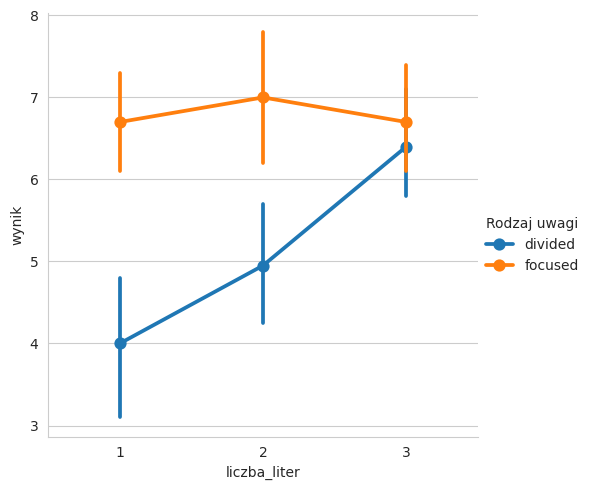

In [95]:
df_tidy = anagrams.melt(
    id_vars=['subidr', 'attnr'],
    var_name='liczba_liter',
    value_name='wynik'
)

mapping = {
    'num1': 1,
    'num2': 2,
    'num3': 3
}

df_tidy['liczba_liter'] = df_tidy['liczba_liter'].map(mapping)
df_tidy = df_tidy.rename(columns={'attnr': 'Rodzaj uwagi'})

g = sns.catplot(
    data=df_tidy,
    x='liczba_liter',
    y='wynik',
    hue='Rodzaj uwagi',
    kind='point',
)

plt.show()